# MLQGPS bands

Three separate blocks load one weight set each and draw the same figures as the multiseed pages.

- Central: `mlqgps_model`
- Upper: `mlqgps_model_upper`
- Lower: `mlqgps_model_lower`

The last cell shades, at each point, the gap between the minimum and maximum of the lower, upper, and central values. Run the three blocks first.


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.integrate import quad, IntegrationWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=IntegrationWarning)

_cwd = os.getcwd()
if os.path.isfile(os.path.join(_cwd, "Thermo_data_central.csv")):
    ROOT = _cwd
elif os.path.isfile(os.path.join(os.path.dirname(_cwd), "Thermo_data_central.csv")):
    ROOT = os.path.dirname(_cwd)
else:
    ROOT = r"d:\ML CURSOR\MLQGP"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT", ROOT)
print("Using device:", device)


ROOT d:\ML CURSOR\MLQGP
Using device: cuda


In [2]:
class Net_Mass(nn.Module):
    def __init__(self, input, output):
        super(Net_Mass, self).__init__()
        self.fc1 = nn.Linear(input, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 64)
        self.fc5 = nn.Linear(64, output)

    def forward(self, x):
        o = self.act(self.fc1(x))
        o = self.act(self.fc2(o))
        o = self.act(self.fc3(o))
        o = self.act(self.fc4(o))
        opt = self.output_layer_act(self.fc5(o))
        return opt

    def act(self, x):
        return x * torch.sigmoid(x)

    def output_layer_act(self, x):
        return torch.sigmoid(x) * 2


def lnZ_q(T, m, mu, eta):
    deg = 50
    xk, wk = np.polynomial.laguerre.laggauss(deg=deg)
    pnodes = torch.from_numpy(xk).to(device)
    wnodes = torch.from_numpy(wk).to(device)
    rnodes = torch.exp(-pnodes)
    psqure = pnodes**2
    E = (psqure + m ** 2) ** 0.5
    E_mu = E - mu
    efactor = torch.exp(-E_mu / T)
    f = efactor * eta
    f = f + 1
    f = torch.log(f)
    f = psqure * eta * f
    f = wnodes * f
    f = f / rnodes
    f = torch.sum(f, 1)
    return f.reshape(-1, 1)


def lnZ_g(T, m, eta):
    deg = 50
    xk, wk = np.polynomial.laguerre.laggauss(deg=deg)
    pnodes = torch.from_numpy(xk).to(device)
    wnodes = torch.from_numpy(wk).to(device)
    rnodes = torch.exp(-pnodes)
    psqure = pnodes**2
    E = (psqure + m ** 2) ** 0.5
    efactor = torch.exp(-E / T)
    f = efactor * eta
    f = f + 1
    f = torch.log(f)
    f = psqure * eta * f
    f = wnodes * f
    f = f / rnodes
    f = torch.sum(f, 1)
    return f.reshape(-1, 1)


In [3]:
from scipy.integrate import quad, IntegrationWarning

TC = 0.155
_thermo = pd.read_csv(os.path.join(ROOT, "Thermo_data_central.csv"))
_T_data = np.sort(np.unique(_thermo["T"].to_numpy(dtype=float)))
T_ARR = _T_data[(_T_data / TC >= 1.10) & (_T_data / TC <= 1.55)]
T_OVER_TC = T_ARR / TC
MU_B_LIST = [0.10, 0.30, 0.60]
MUHAT_LIST = [0, 1, 2, 3]
SEEB_HAT = [1, 2, 3]
NC = 3
LAMBDA_WB, TS_TC_WB, KWB = 2.6, 0.57, 18.5
FM_TO_GEVINV = 5.07
E_EM = np.sqrt(4.0 * np.pi / 137.0)
G_I = 2 * NC

SPECIES = [
    ("u",    +2.0 / 3.0, +1.0 / 3.0, 6, "ud"),
    ("ubar", -2.0 / 3.0, -1.0 / 3.0, 6, "ud"),
    ("d",    -1.0 / 3.0, +1.0 / 3.0, 6, "ud"),
    ("dbar", +1.0 / 3.0, -1.0 / 3.0, 6, "ud"),
    ("s",    -1.0 / 3.0, +1.0 / 3.0, 6, "s"),
    ("sbar", +1.0 / 3.0, -1.0 / 3.0, 6, "s"),
]
HAT_COLORS = ["C0", "C1", "C2", "C3"]
HAT_STYLES = ["-", "--", "-.", ":"]
B_COLORS = ["black", "C3", "C0"]
B_STYLES = ["-", "--", "-."]


def g2_plumari(T):
    return 48.0 * np.pi**2 / (((11 * NC) - (2 * NC)) * np.log((LAMBDA_WB * (float(T) / TC - TS_TC_WB))**2))


def tau_q(T):
    g2 = g2_plumari(T)
    tau_fm = (((NC**2 - 1) / NC) * (g2 * float(T)) / (8.0 * np.pi) * np.log(2.0 * KWB / g2) * FM_TO_GEVINV) ** (-1)
    return tau_fm * FM_TO_GEVINV


def load_nets(folder):
    nets = []
    for name in ("MLQGPS_Mud.pt", "MLQGPS_Ms.pt", "MLQGPS_Mg.pt"):
        net = Net_Mass(2, 1).to(device)
        ckpt = torch.load(os.path.join(folder, name), map_location=device, weights_only=False)
        net.load_state_dict(ckpt["state_dict"])
        net.eval()
        nets.append(net)
    return nets


def masses_thermo(nets, T_val, muB_val):
    net_mud, net_ms, net_mg = nets
    T = torch.tensor([[float(T_val)]], dtype=torch.float32, device=device, requires_grad=True)
    muB = torch.tensor([[float(muB_val)]], dtype=torch.float32, device=device, requires_grad=True)
    inp = torch.cat((T, muB), 1)
    Mud = net_mud(inp)
    Ms = net_ms(inp)
    Mg = net_mg(inp)
    mu_q = muB / 3.0
    coef = 1.0 / (2.0 * torch.pi**2)
    ud_dof = 2 * 2 * 3
    s_dof = 2 * 3
    gluon_dof = 8 * 2
    lnZ = (
        ud_dof * coef * (lnZ_q(T, Mud, mu_q, 1) + lnZ_q(T, Mud, -mu_q, 1))
        + s_dof * coef * (lnZ_q(T, Ms, mu_q, 1) + lnZ_q(T, Ms, -mu_q, 1))
        + gluon_dof * coef * lnZ_g(T, Mg, -1)
    )
    dlnZdT = torch.autograd.grad(lnZ, T, grad_outputs=torch.ones_like(T), retain_graph=True)[0]
    dlnZdmu = torch.autograd.grad(lnZ, muB, grad_outputs=torch.ones_like(muB))[0]
    P = float((T * lnZ).detach().reshape(-1)[0])
    nB = float((T * dlnZdmu).detach().reshape(-1)[0])
    s = float((T * dlnZdT + lnZ).detach().reshape(-1)[0])
    eps = float(T_val) * s - P + float(muB_val) * nB
    return (
        float(Mud.detach().reshape(-1)[0]),
        float(Ms.detach().reshape(-1)[0]),
        float(Mg.detach().reshape(-1)[0]),
        eps, P, nB,
    )


def f0(w, T, mu_B, b):
    return 1.0 / (np.exp((w - b * mu_B) / T) + 1.0)


def sigma_integrand(k, m, T, tau, mu_B, q, b):
    w = np.sqrt(k**2 + m**2)
    f = f0(w, T, mu_B, b)
    return k**2 / (2 * np.pi**2) * (G_I / (3 * T)) * tau * q**2 * (k / w)**2 * f * (1 - f)


def I1_integrand(k, m, T, tau, mu_B, q, b, xi):
    w = np.sqrt(k**2 + m**2)
    f = f0(w, T, mu_B, b)
    return k**2 / (2 * np.pi**2) * (G_I / (3 * T)) * tau * q * (k / w)**2 * (w - b * xi) * f * (1 - f)


def transport_at_point(T, muB, m_ud, m_s, eps, P, nB):
    if not np.isfinite(nB) or abs(nB) < 1e-12:
        return np.nan, np.nan, np.nan
    xi = (eps + P) / nB
    if not np.isfinite(xi):
        return np.nan, np.nan, np.nan
    tau = float(tau_q(T))
    sigma = 0.0
    I1 = 0.0
    for _name, qfrac, b, _g, key in SPECIES:
        m = float(m_ud if key == "ud" else m_s)
        q = qfrac * E_EM
        s_i, _ = quad(sigma_integrand, 0, 10, args=(m, float(T), tau, float(muB), q, b))
        i_i, _ = quad(I1_integrand, 0, 10, args=(m, float(T), tau, float(muB), q, b, float(xi)))
        sigma += s_i
        I1 += i_i
    if not np.isfinite(sigma) or sigma == 0.0:
        return np.nan, np.nan, np.nan
    sigT = sigma / float(T)
    IT = I1 / float(T)**2
    S = IT / sigT
    return sigT, IT, S


def curves_for_nets(nets, label):
    n_T = len(T_ARR)
    T_arr = T_ARR
    mass_u_hat = np.empty((len(MUHAT_LIST), n_T))
    mass_s_hat = np.empty((len(MUHAT_LIST), n_T))
    mass_g_hat = np.empty((len(MUHAT_LIST), n_T))
    for i, muhat in enumerate(MUHAT_LIST):
        for j, T in enumerate(T_arr):
            muB = muhat * float(T)
            mud, ms, mg, _eps, _P, _nB = masses_thermo(nets, T, muB)
            mass_u_hat[i, j] = mud
            mass_s_hat[i, j] = ms
            mass_g_hat[i, j] = mg
    seebeck_hat = np.full((len(SEEB_HAT), n_T), np.nan)
    for i, muhat in enumerate(SEEB_HAT):
        print(label, "Seebeck MuBhat =", muhat, flush=True)
        for j, T in enumerate(T_arr):
            muB = muhat * float(T)
            mud, ms, _mg, eps, P, nB = masses_thermo(nets, T, muB)
            _sig, _IT, seebeck_hat[i, j] = transport_at_point(float(T), muB, mud, ms, eps, P, nB)
    mass_u_b = np.empty((len(MU_B_LIST), n_T))
    mass_s_b = np.empty((len(MU_B_LIST), n_T))
    mass_g_b = np.empty((len(MU_B_LIST), n_T))
    sigT = np.full((len(MU_B_LIST), n_T), np.nan)
    IT = np.full_like(sigT, np.nan)
    seebeck_b = np.full_like(sigT, np.nan)
    for i, muB in enumerate(MU_B_LIST):
        print(label, "fixed MuB =", muB, flush=True)
        for j, T in enumerate(T_arr):
            mud, ms, mg, eps, P, nB = masses_thermo(nets, T, muB)
            mass_u_b[i, j] = mud
            mass_s_b[i, j] = ms
            mass_g_b[i, j] = mg
            sigT[i, j], IT[i, j], seebeck_b[i, j] = transport_at_point(float(T), muB, mud, ms, eps, P, nB)
    return {
        "mass_u_hat": mass_u_hat,
        "mass_s_hat": mass_s_hat,
        "mass_g_hat": mass_g_hat,
        "mass_u_b": mass_u_b,
        "mass_s_b": mass_s_b,
        "mass_g_b": mass_g_b,
        "sigT": sigT,
        "IT": IT,
        "seebeck_b": seebeck_b,
        "seebeck_hat": seebeck_hat,
    }


def _style_labels():
    hat_labels = [r"$\hat{\mu}_B = %d$" % h for h in MUHAT_LIST]
    b_labels = [r"$\mu_B = %.2f$ GeV" % mu for mu in MU_B_LIST]
    return hat_labels, b_labels


def _seeb_hat_style():
    labels = [r"$\hat{\mu}_B = %d$" % h for h in SEEB_HAT]
    idx = [MUHAT_LIST.index(h) for h in SEEB_HAT]
    colors = [HAT_COLORS[i] for i in idx]
    styles = [HAT_STYLES[i] for i in idx]
    return labels, colors, styles


def _draw(ax, data, labels, colors, styles, ylabel, title):
    for i, lab in enumerate(labels):
        ax.plot(T_OVER_TC, data[i], color=colors[i], linestyle=styles[i], label=lab)
    ax.set_xlabel(r"$T/T_c$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)


def _panel_page(label, pairs):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
    for ax, spec in zip(axes.ravel(), pairs):
        data, labels, colors, styles, ylabel, title = spec
        _draw(ax, data, labels, colors, styles, ylabel, title)
    fig.suptitle(label, fontsize=16)
    return fig


def mass_seebeck_grid(label, curves):
    fig, axes = plt.subplots(
        2, 3, sharex=True, sharey="row", figsize=(16, 8.2),
        gridspec_kw={"hspace": 0.16, "wspace": 0.22},
    )
    for j, muB in enumerate(MU_B_LIST):
        ax_m, ax_S = axes[0, j], axes[1, j]
        ax_m.plot(T_OVER_TC, curves["mass_u_b"][j], color="#2A9D8F", lw=2, label=r"$m_{u,d}$ [GeV]")
        ax_m.plot(T_OVER_TC, curves["mass_s_b"][j], color="#3A86FF", lw=2, label=r"$m_s$ [GeV]")
        ax_m.plot(T_OVER_TC, curves["mass_g_b"][j], color="#E76F51", lw=2, label=r"$m_g$ [GeV]")
        ax_m.set_title(r"$\mu_B=%.1f$ GeV" % muB, fontsize=18)
        ax_m.grid(True)
        ax_S.plot(T_OVER_TC, curves["seebeck_b"][j], color="black", lw=2, ls="--", label=r"$S$")
        ax_S.set_xlabel(r"$T/T_c$", fontsize=16)
        ax_S.set_xlim(1.1, 1.55)
        ax_S.grid(True)
        if j == 0:
            ax_m.set_ylabel(r"$m$ [GeV]", fontsize=16)
            ax_S.set_ylabel(r"$S$", fontsize=16)
            ax_m.legend(loc="lower left", fontsize=11)
            ax_S.legend(loc="upper right", fontsize=11)
    fig.suptitle(label + "    masses and Seebeck", fontsize=16)
    fig.subplots_adjust(top=0.88)
    return fig


def show_weight_set(label, curves):
    hat_labels, b_labels = _style_labels()
    seeb_labels, seeb_colors, seeb_styles = _seeb_hat_style()
    pages = [
        _panel_page(label + "    masses at $\\hat{\\mu}_B$", [
            (curves["mass_u_hat"], hat_labels, HAT_COLORS, HAT_STYLES, r"$m_u$ [GeV]", r"$m_u$    $\hat{\mu}_B$"),
            (curves["mass_u_hat"], hat_labels, HAT_COLORS, HAT_STYLES, r"$m_d$ [GeV]", r"$m_d$    $\hat{\mu}_B$"),
            (curves["mass_s_hat"], hat_labels, HAT_COLORS, HAT_STYLES, r"$m_s$ [GeV]", r"$m_s$    $\hat{\mu}_B$"),
            (curves["mass_g_hat"], hat_labels, HAT_COLORS, HAT_STYLES, r"$m_g$ [GeV]", r"$m_g$    $\hat{\mu}_B$"),
        ]),
        _panel_page(label + "    masses at fixed $\\mu_B$", [
            (curves["mass_u_b"], b_labels, B_COLORS, B_STYLES, r"$m_u$ [GeV]", r"$m_u$    fixed $\mu_B$"),
            (curves["mass_u_b"], b_labels, B_COLORS, B_STYLES, r"$m_d$ [GeV]", r"$m_d$    fixed $\mu_B$"),
            (curves["mass_s_b"], b_labels, B_COLORS, B_STYLES, r"$m_s$ [GeV]", r"$m_s$    fixed $\mu_B$"),
            (curves["mass_g_b"], b_labels, B_COLORS, B_STYLES, r"$m_g$ [GeV]", r"$m_g$    fixed $\mu_B$"),
        ]),
        _panel_page(label + "    transport", [
            (curves["sigT"], b_labels, B_COLORS, B_STYLES, r"$\sigma_{\mathrm{el}}/T$", r"$\sigma_{\mathrm{el}}/T$"),
            (curves["IT"], b_labels, B_COLORS, B_STYLES, r"$I_1/T^2$", r"$I_1/T^2$"),
            (curves["seebeck_b"], b_labels, B_COLORS, B_STYLES, r"$S$", r"Seebeck    fixed $\mu_B$"),
            (curves["seebeck_hat"], seeb_labels, seeb_colors, seeb_styles, r"$S$", r"Seebeck    $\hat{\mu}_B = 1,2,3$"),
        ]),
        mass_seebeck_grid(label, curves),
    ]
    for fig in pages:
        plt.show()
    return pages


def evaluate_folder(folder_name, label):
    folder = os.path.join(ROOT, folder_name)
    print(label, folder, flush=True)
    nets = load_nets(folder)
    curves = curves_for_nets(nets, label)
    show_weight_set(label, curves)
    return curves


## Central

Weights in `mlqgps_model`.


Central d:\ML CURSOR\MLQGP\mlqgps_model
Central Seebeck MuBhat = 1
Central Seebeck MuBhat = 2
Central Seebeck MuBhat = 3
Central fixed MuB = 0.1
Central fixed MuB = 0.3
Central fixed MuB = 0.6


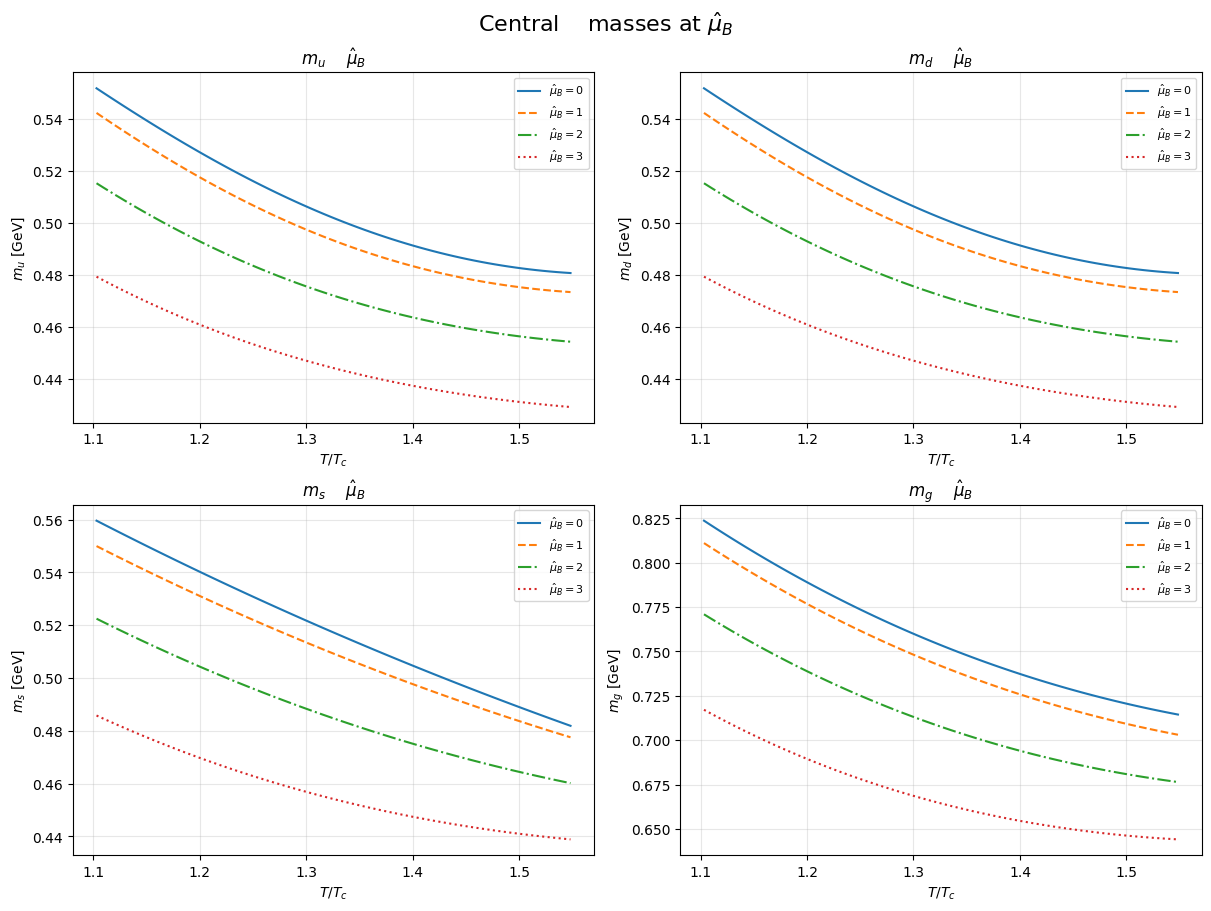

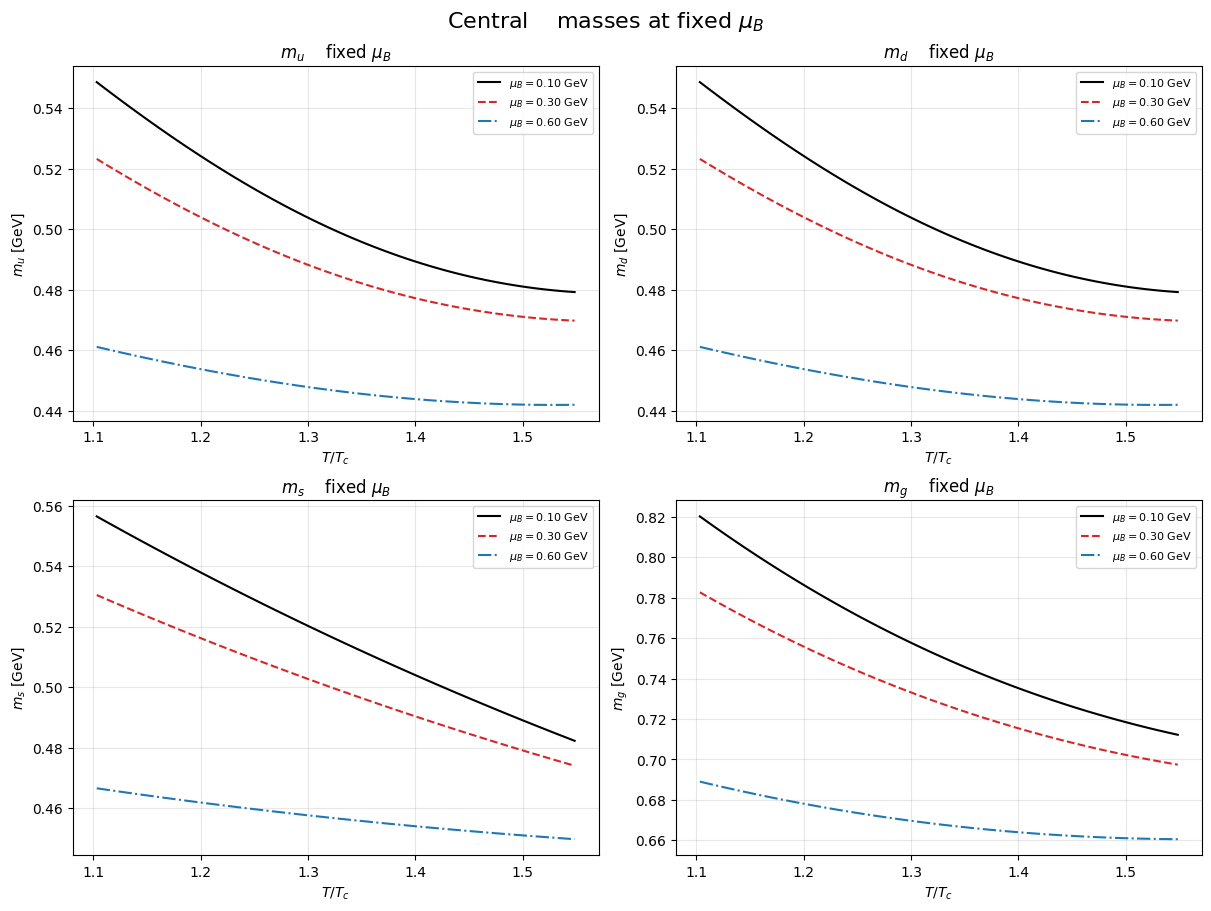

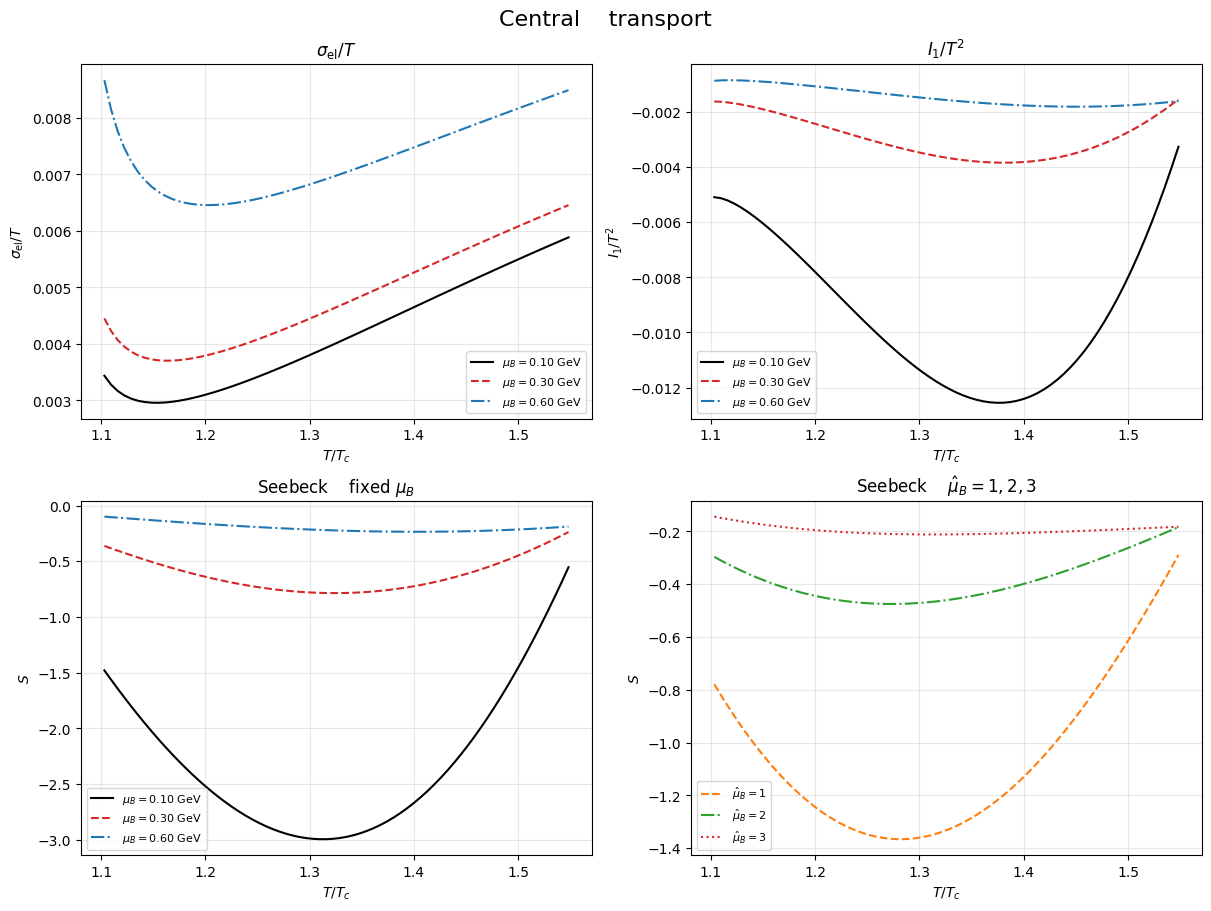

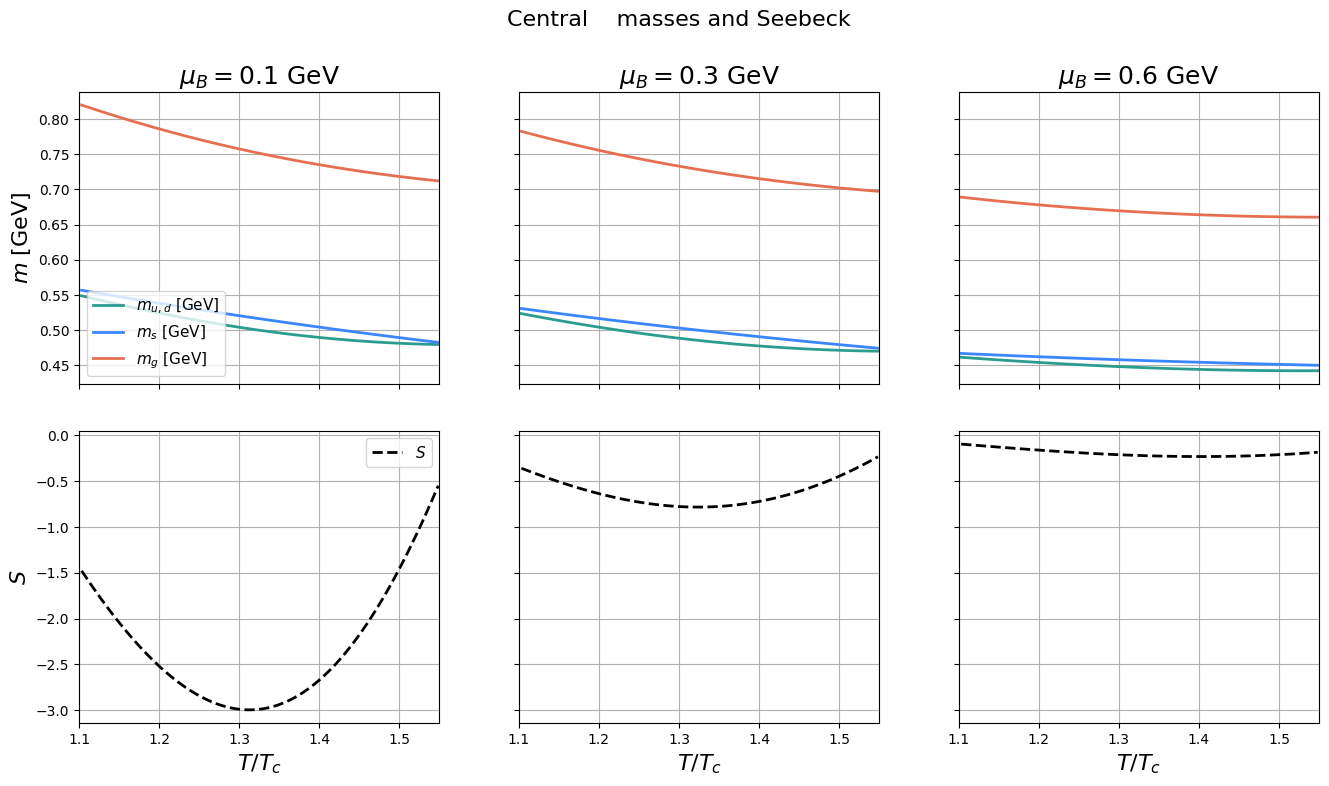

In [4]:
curves_central = evaluate_folder("mlqgps_model", "Central")


## Upper

Weights in `mlqgps_model_upper`.


Upper d:\ML CURSOR\MLQGP\mlqgps_model_upper
Upper Seebeck MuBhat = 1
Upper Seebeck MuBhat = 2
Upper Seebeck MuBhat = 3
Upper fixed MuB = 0.1
Upper fixed MuB = 0.3
Upper fixed MuB = 0.6


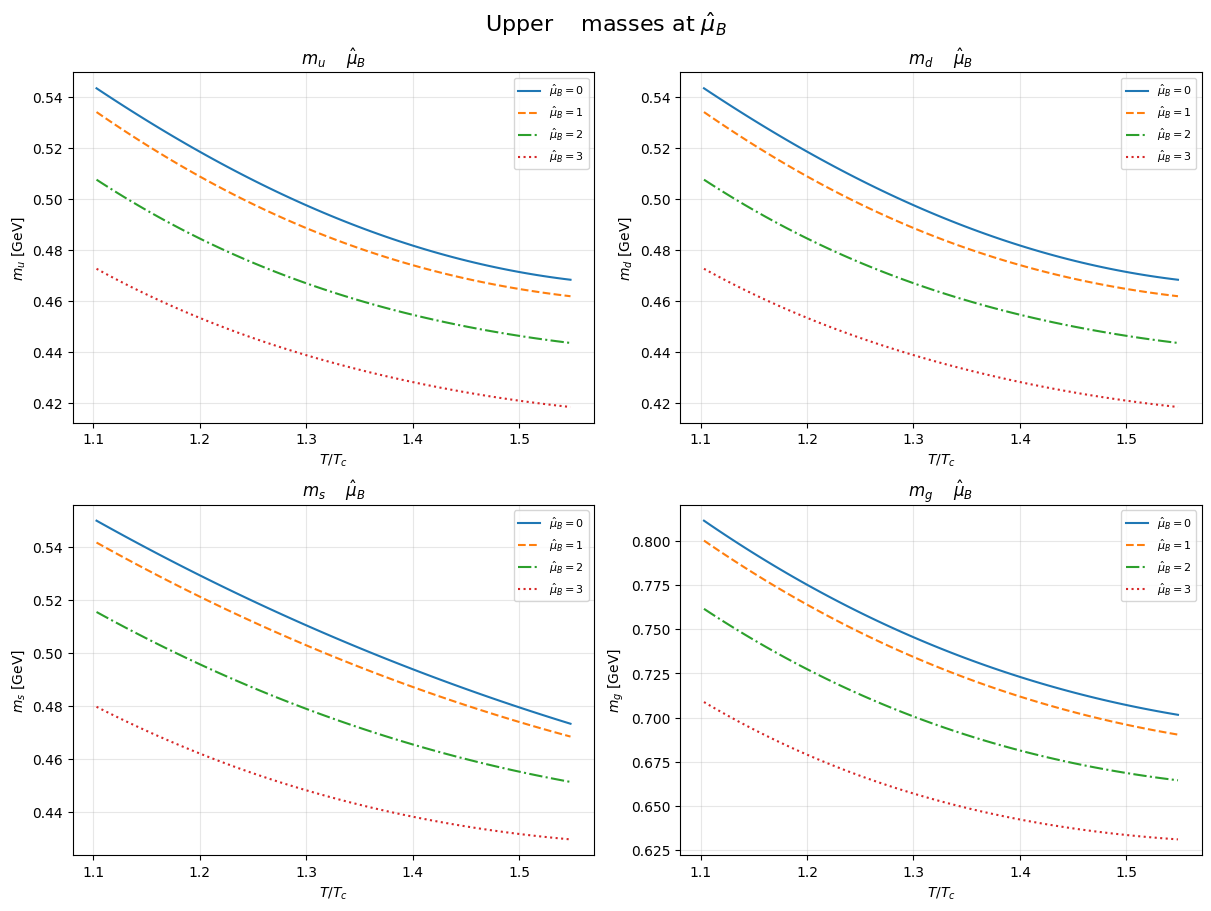

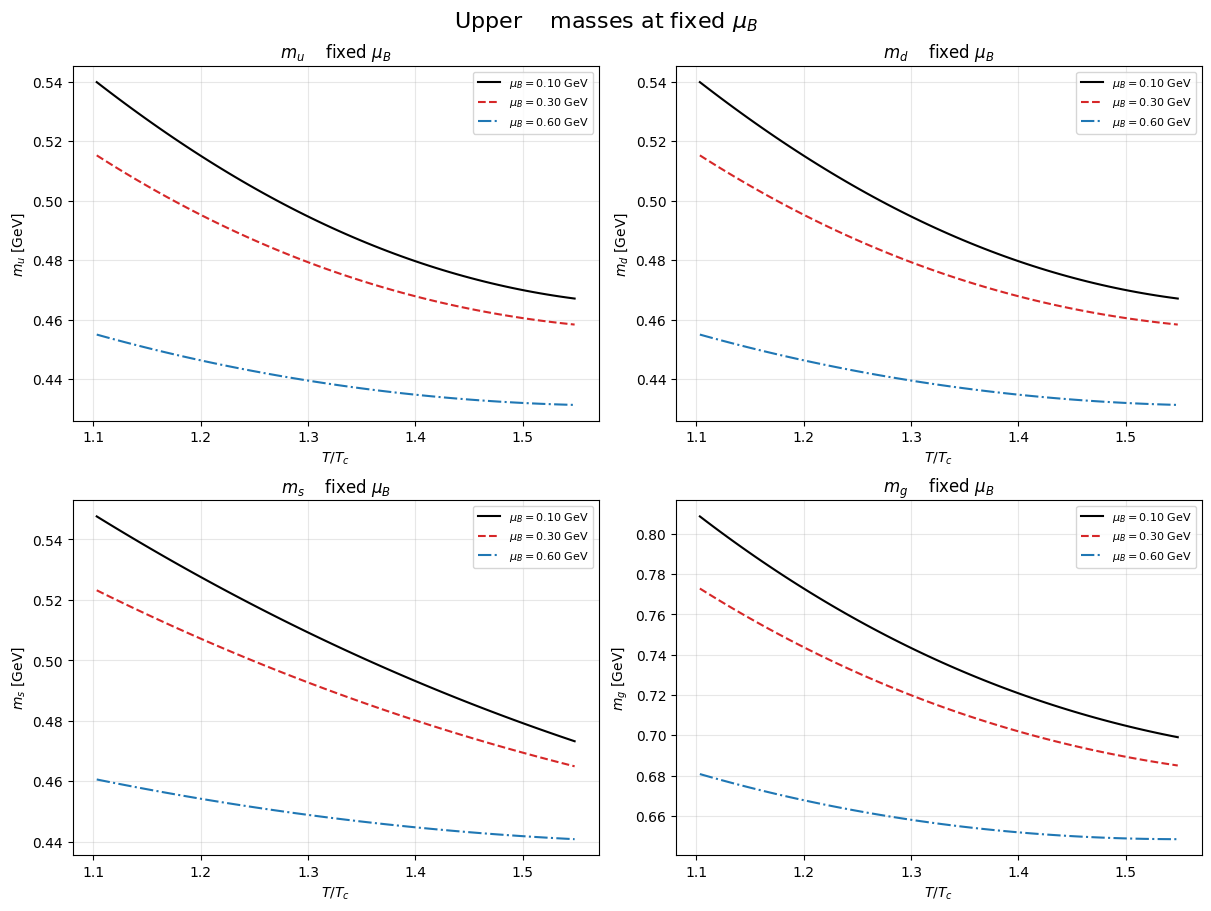

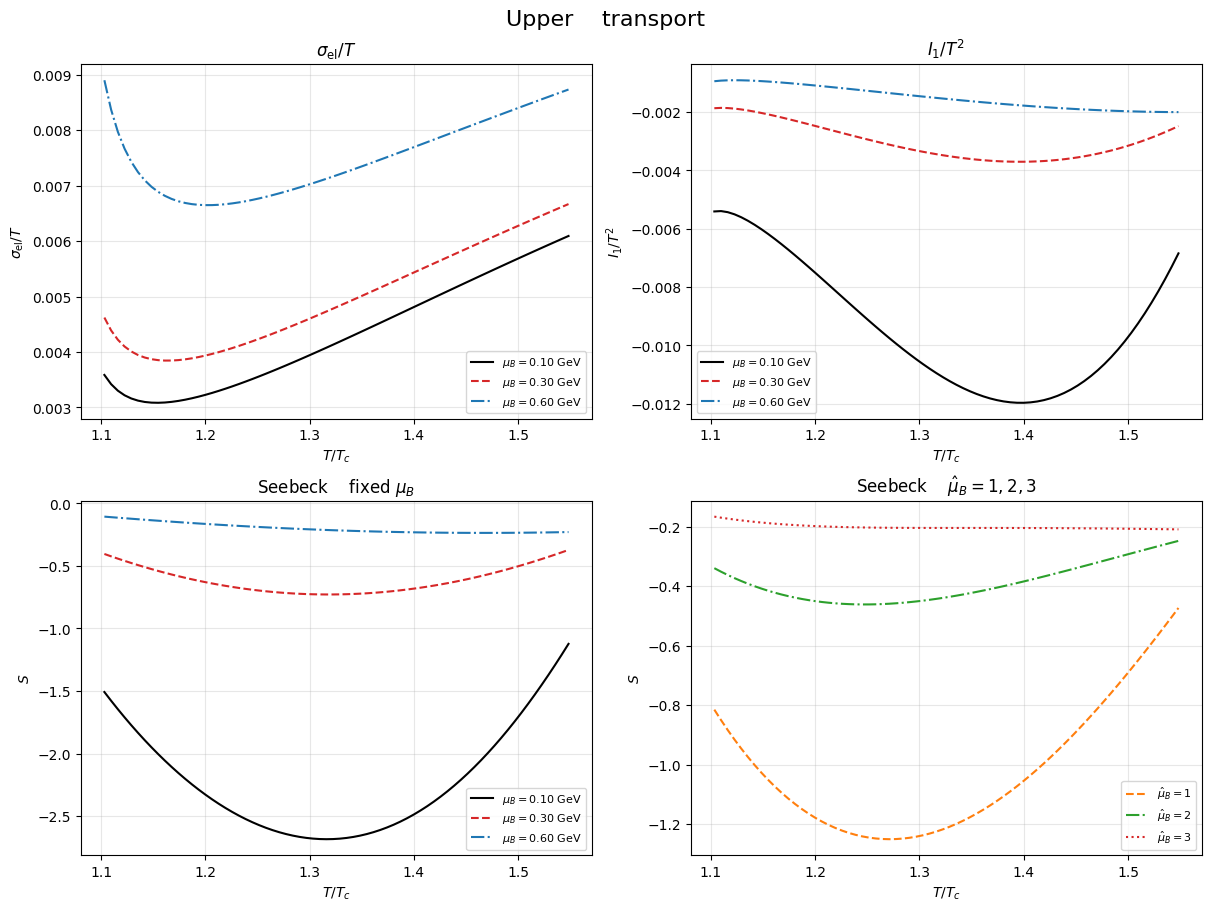

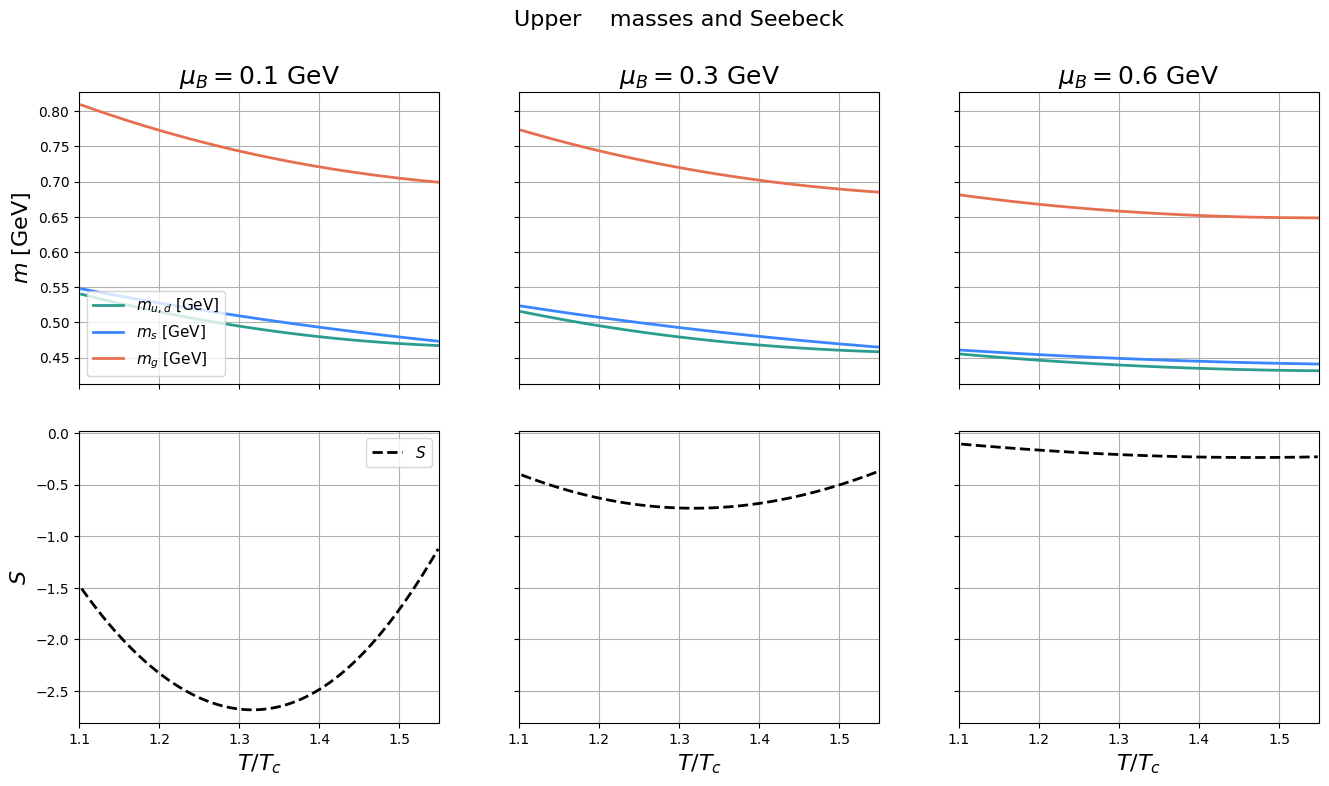

In [5]:
curves_upper = evaluate_folder("mlqgps_model_upper", "Upper")


## Lower

Weights in `mlqgps_model_lower`.


Lower d:\ML CURSOR\MLQGP\mlqgps_model_lower
Lower Seebeck MuBhat = 1
Lower Seebeck MuBhat = 2
Lower Seebeck MuBhat = 3
Lower fixed MuB = 0.1
Lower fixed MuB = 0.3
Lower fixed MuB = 0.6


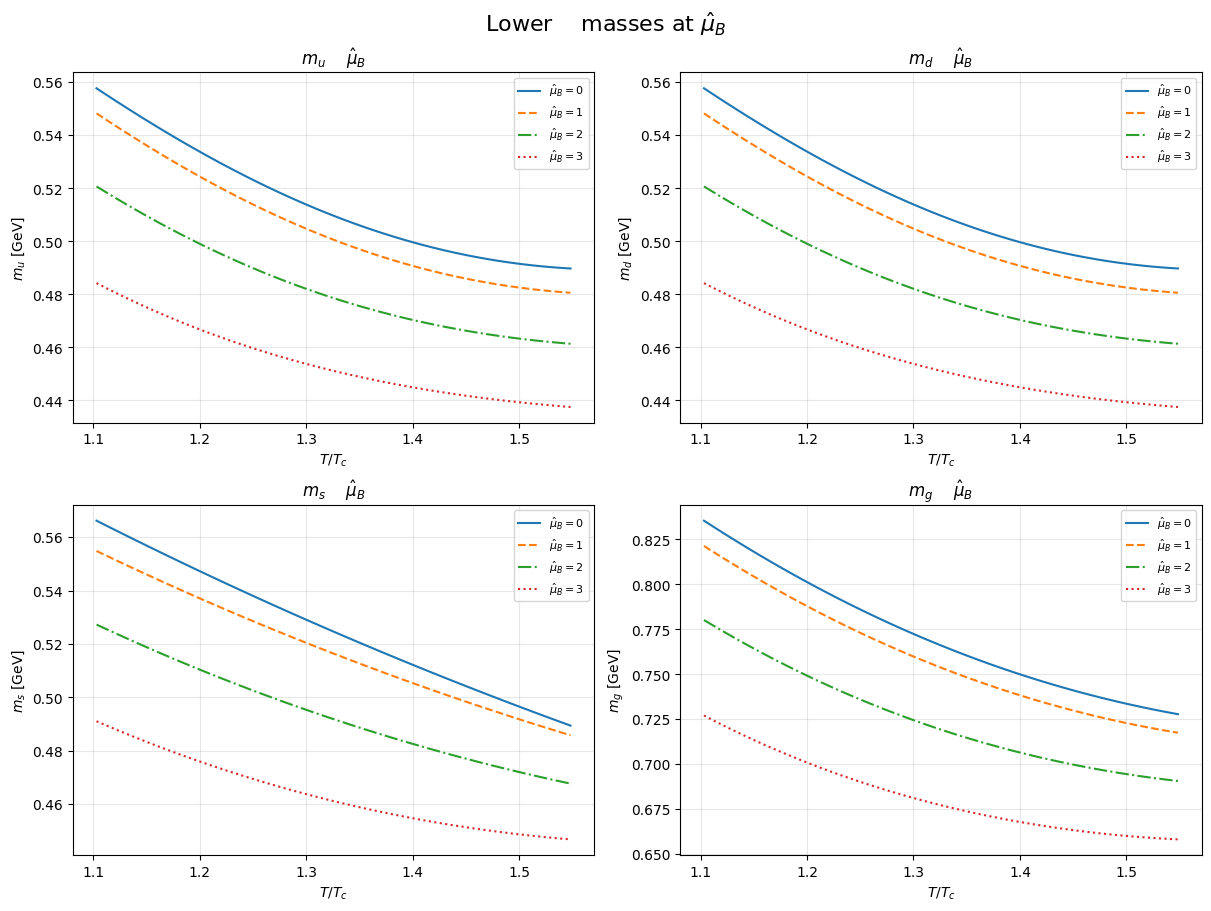

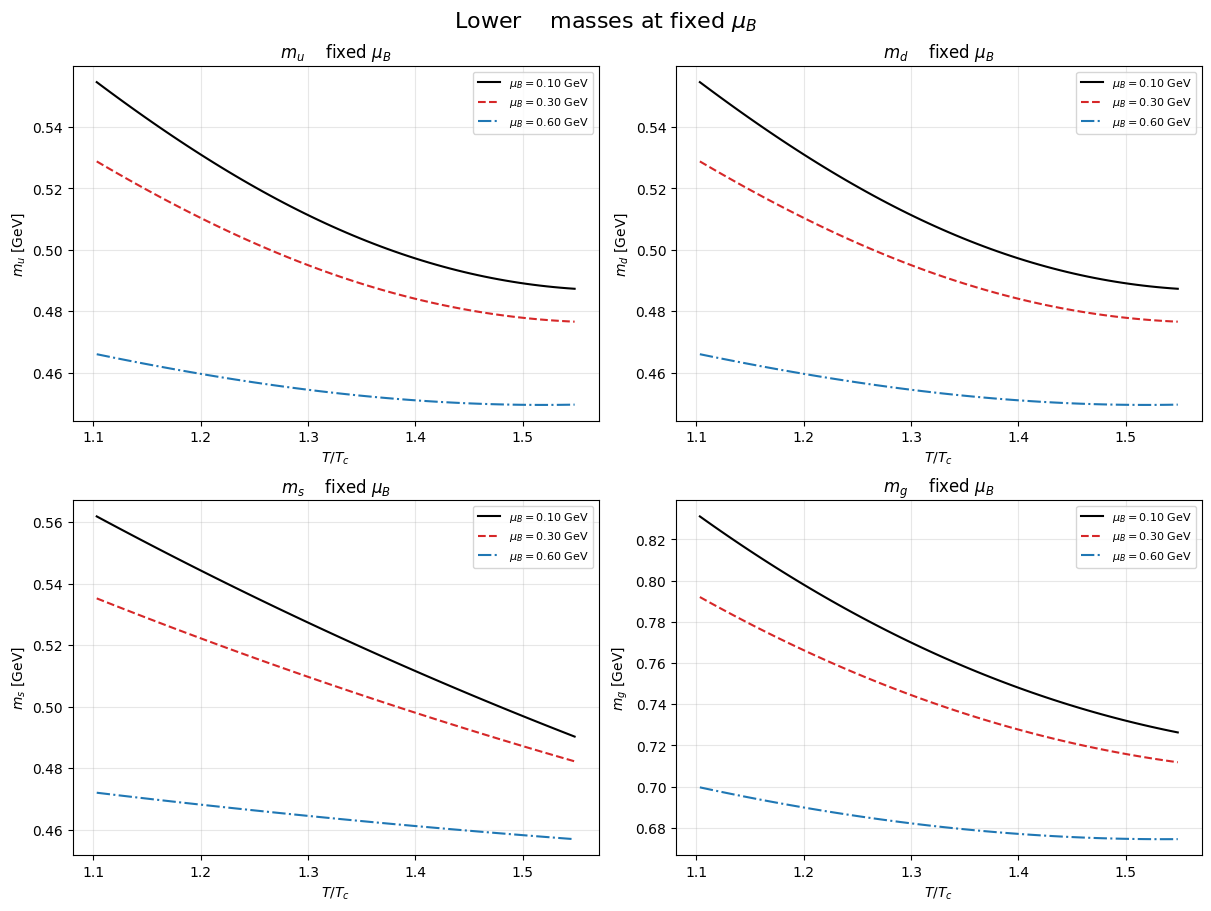

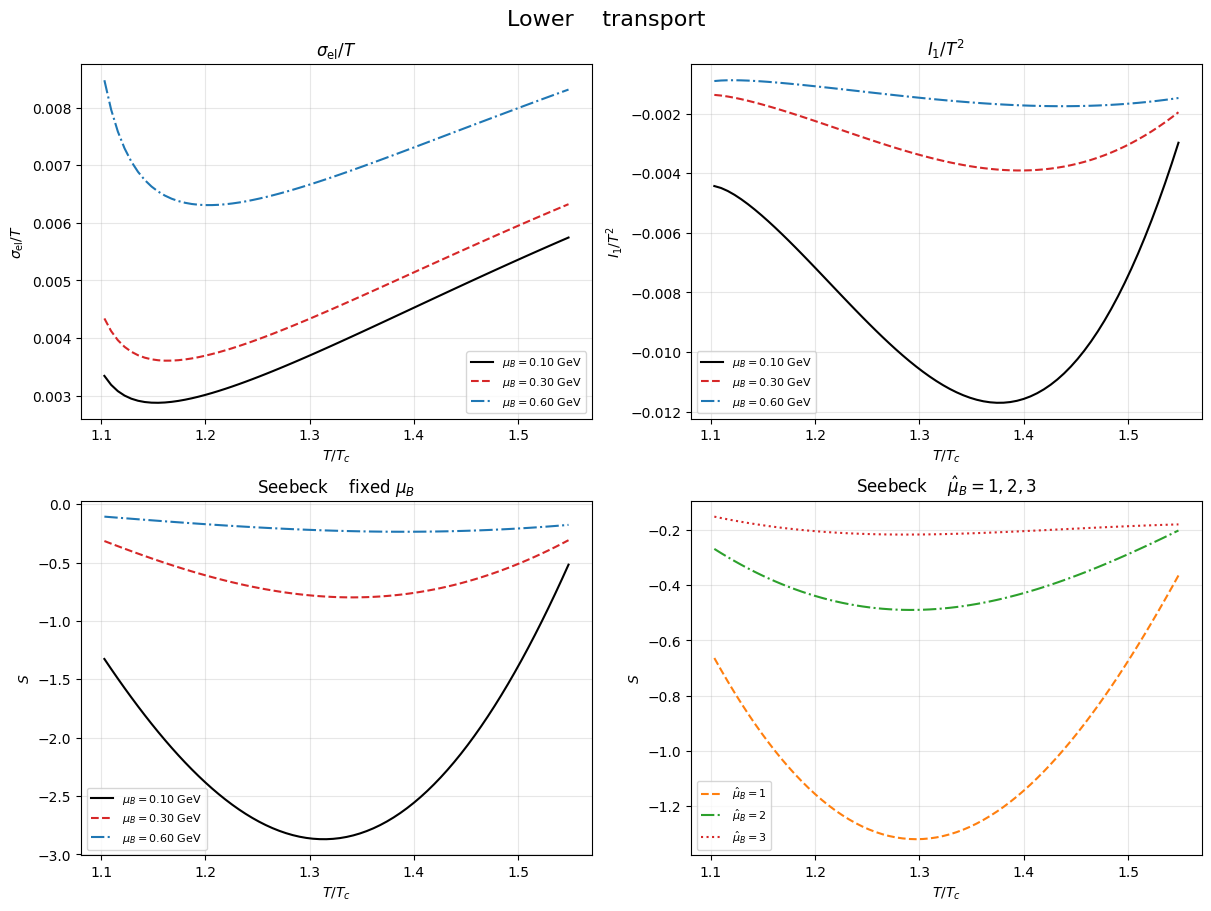

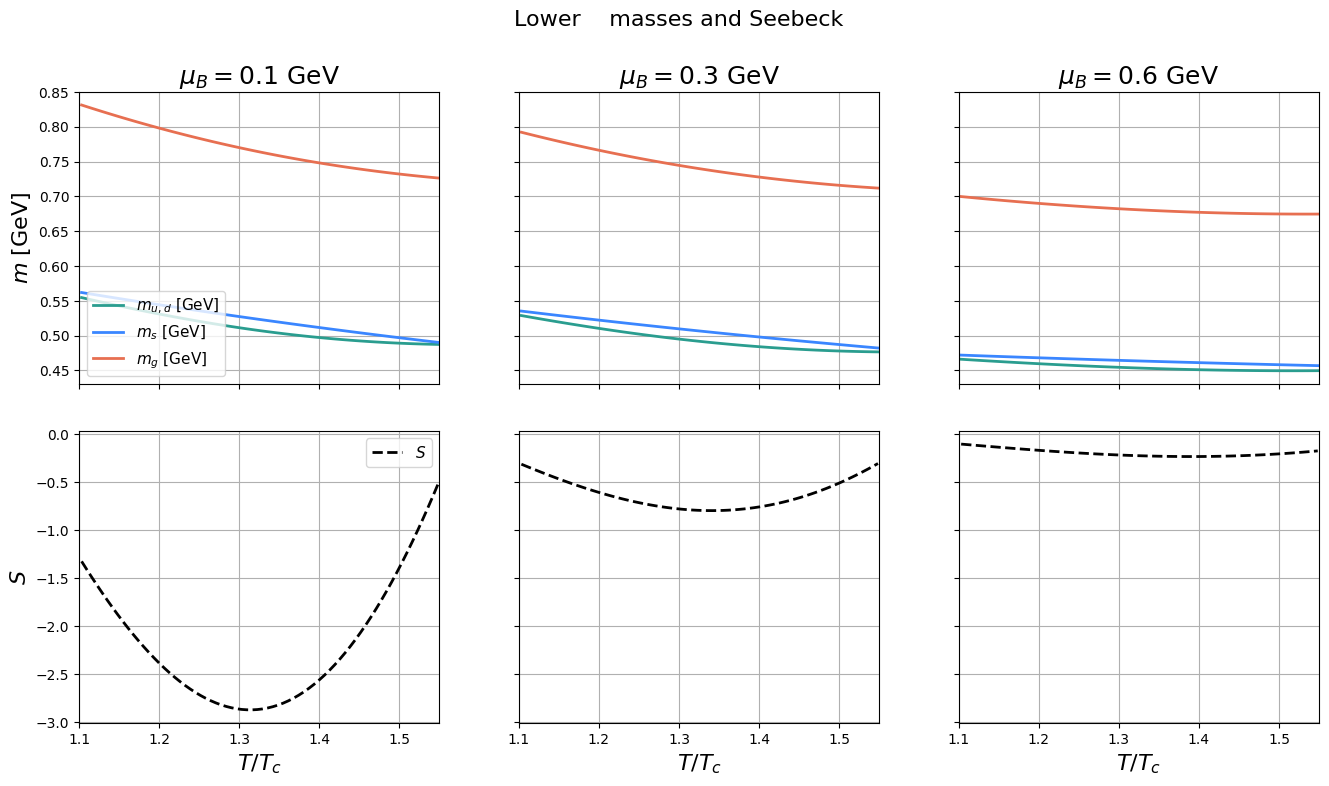

In [6]:
curves_lower = evaluate_folder("mlqgps_model_lower", "Lower")


## Band

The shaded region is the gap between the minimum and the maximum of the lower, upper, and central values at that point.


In [ ]:
def _minmax(lower, upper, central):
    stack = np.stack([np.asarray(lower), np.asarray(upper), np.asarray(central)], axis=0)
    return np.nanmin(stack, axis=0), np.nanmax(stack, axis=0)


def _band_on(ax, lower, upper, central, labels, colors):
    lo, hi = _minmax(lower, upper, central)
    for i, lab in enumerate(labels):
        ax.fill_between(T_OVER_TC, lo[i], hi[i], color=colors[i], alpha=0.22, label=lab)
        ax.plot(T_OVER_TC, hi[i], color=colors[i], linestyle='-', linewidth=1.2)
        ax.plot(T_OVER_TC, lo[i], color=colors[i], linestyle='-', linewidth=1.2)
    ax.set_xlabel(r'/T_c$')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)


def show_band(lower, upper, central):
    hat_labels, b_labels = _style_labels()
    seeb_labels, seeb_colors, _seeb_styles = _seeb_hat_style()
    specs = [
        ('mass_u_hat', hat_labels, HAT_COLORS, r'$ [GeV]', r'$    $\hat{\mu}_B$'),
        ('mass_u_hat', hat_labels, HAT_COLORS, r'$ [GeV]', r'$    $\hat{\mu}_B$'),
        ('mass_s_hat', hat_labels, HAT_COLORS, r'$ [GeV]', r'$    $\hat{\mu}_B$'),
        ('mass_g_hat', hat_labels, HAT_COLORS, r'$ [GeV]', r'$    $\hat{\mu}_B$'),
        ('mass_u_b', b_labels, B_COLORS, r'$ [GeV]', r'$    fixed $\mu_B$'),
        ('mass_u_b', b_labels, B_COLORS, r'$ [GeV]', r'$    fixed $\mu_B$'),
        ('mass_s_b', b_labels, B_COLORS, r'$ [GeV]', r'$    fixed $\mu_B$'),
        ('mass_g_b', b_labels, B_COLORS, r'$ [GeV]', r'$    fixed $\mu_B$'),
        ('sigT', b_labels, B_COLORS, r'$\sigma_{\mathrm{el}}/T$', r'$\sigma_{\mathrm{el}}/T$'),
        ('IT', b_labels, B_COLORS, r'/T^2$', r'/T^2$'),
        ('seebeck_b', b_labels, B_COLORS, r'$', r'Seebeck    fixed $\mu_B$'),
        ('seebeck_hat', seeb_labels, seeb_colors, r'$', r'Seebeck    $\hat{\mu}_B = 1,2,3$'),
    ]
    for key, labels, colors, ylabel, title in specs:
        fig, ax = plt.subplots(figsize=(7.2, 4.4))
        _band_on(ax, lower[key], upper[key], central[key], labels, colors)
        ax.set_ylabel(ylabel)
        ax.set_title('Band    ' + title)
        fig.tight_layout()
        plt.show()

    fig, axes = plt.subplots(
        2, 3, sharex=True, figsize=(16, 8.2),
        gridspec_kw={'hspace': 0.16, 'wspace': 0.22},
    )
    for j, muB in enumerate(MU_B_LIST):
        ax_m, ax_S = axes[0, j], axes[1, j]
        for key, color, name in (
            ('mass_u_b', '#2A9D8F', r'{u,d}$'),
            ('mass_s_b', '#3A86FF', r'$'),
            ('mass_g_b', '#E76F51', r'$'),
        ):
            lo, hi = _minmax(lower[key][j], upper[key][j], central[key][j])
            ax_m.fill_between(T_OVER_TC, lo, hi, color=color, alpha=0.22, label=name)
            ax_m.plot(T_OVER_TC, hi, color=color, ls='-', lw=1.2)
            ax_m.plot(T_OVER_TC, lo, color=color, ls='-', lw=1.2)
        ax_m.set_title(r'$\mu_B=%.1f$ GeV' % muB, fontsize=18)
        ax_m.grid(True)
        lo, hi = _minmax(lower['seebeck_b'][j], upper['seebeck_b'][j], central['seebeck_b'][j])
        ax_S.fill_between(T_OVER_TC, lo, hi, color='0.5', alpha=0.25, label=r'$')
        ax_S.plot(T_OVER_TC, hi, color='black', ls='-', lw=1.2)
        ax_S.plot(T_OVER_TC, lo, color='black', ls='-', lw=1.2)
        ax_S.set_xlabel(r'/T_c$', fontsize=16)
        ax_S.set_xlim(1.1, 1.55)
        ax_S.grid(True)
        if j == 0:
            ax_m.set_ylabel(r'$ [GeV]', fontsize=16)
            ax_S.set_ylabel(r'$', fontsize=16)
            ax_m.legend(loc='lower left', fontsize=11)
            ax_S.legend(loc='upper right', fontsize=11)
    fig.suptitle('Band    masses and Seebeck', fontsize=16)
    fig.subplots_adjust(top=0.88)
    plt.show()


show_band(curves_lower, curves_upper, curves_central)


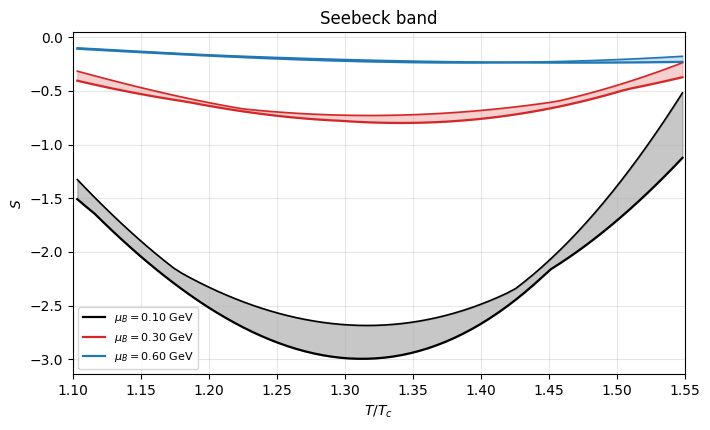

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# shape (3 weight sets, 3 MuB, nT)
S_stack = np.stack([
    curves_lower["seebeck_b"],
    curves_upper["seebeck_b"],
    curves_central["seebeck_b"],
], axis=0)

S_min = np.nanmin(S_stack, axis=0)
S_max = np.nanmax(S_stack, axis=0)

fig, ax = plt.subplots(figsize=(7.2, 4.4))
for i, muB in enumerate(MU_B_LIST):
    ax.fill_between(T_OVER_TC, S_min[i], S_max[i], color=B_COLORS[i], alpha=0.22)
    ax.plot(T_OVER_TC, S_max[i], color=B_COLORS[i], linestyle="-", linewidth=1.2)
    ax.plot(T_OVER_TC, S_min[i], color=B_COLORS[i], linestyle="-", linewidth=1.6,
            label=r"$\mu_B = %.2f$ GeV" % muB)
ax.set_xlabel(r"$T/T_c$")
ax.set_ylabel(r"$S$")
ax.set_title(r"Seebeck band")
ax.set_xlim(1.1, 1.55)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()